# EM Edition - The Original Sin Reversal

## Overview
This analysis tracks the historic "Original Sin Reversal" using **real market data** - the structural shift where disciplined Emerging Markets now offer superior fiscal positions and real yields compared to debt-laden G7 nations. We monitor two critical indicators using live financial data:

### 1. The Credibility Gap (G7 vs. EM Real Rate Gap)
Using real government bond yields from FRED API and market sources, we track EM "Fiscal Adult" nations versus G7's weighted average real yields. This creates measurable capital flow signals toward where the math works - disciplined EM countries operating with a "Safety Buffer" while G7 hits the "Fiscal Ceiling."

### 2. The Fiscal Divergence (Primary Surplus Trajectory) 
Using **World Bank API** data (indicator: `GC.NLD.TOTL.GD.ZS` — net lending/borrowing as % of GDP) for both G7 and EM countries. This tracks how US/UK fiscal positions compare against the fiscal discipline of countries like Indonesia and Mexico.

### Data Sources
- **Bond Yields**: FRED API (G7 and EM 10-year government bond yields)
- **Inflation**: FRED API (CPI data for real yield calculation)
- **Fiscal Data**: World Bank API (net lending/borrowing, % of GDP)
- **No synthetic or fabricated data** — only countries with available API data are included


## Environment Setup and Dependencies

In [1]:
# Install required packages if not available
required_packages = ['pandas-datareader', 'requests', 'wbdata']
for package in required_packages:
    try:
        __import__(package.replace('-', '_'))
        print(f"✓ {package} is available")
    except ImportError:
        print(f"Installing {package}...")
        import subprocess
        import sys
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', package])
        print(f"✓ {package} installation complete!")

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas_datareader.data as web
import requests
import json
import warnings
from datetime import datetime, timedelta

# Configure display and warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
plt.style.use('default')

# Set analysis parameters
start_date = datetime(2020, 1, 1)
end_date = datetime.now()
print(f"📊 Analysis period: {start_date.strftime('%Y-%m-%d')} to {end_date.strftime('%Y-%m-%d')}")
print("🔧 Environment setup complete with real EM data capabilities!")

✓ pandas-datareader is available
✓ requests is available
✓ wbdata is available
📊 Analysis period: 2020-01-01 to 2026-03-15
🔧 Environment setup complete with real EM data capabilities!


In [2]:
# Real Data Collection: G7 + Emerging Markets
print("🌍 FETCHING REAL FINANCIAL DATA - G7 & EM")
print("=" * 50)

# ============================================================================
# G7 GOVERNMENT BOND YIELDS (REAL DATA FROM FRED)
# ============================================================================
print("📊 Fetching G7 Government Bond Yields...")
g7_yields = {}
g7_symbols = {
    'US': 'DGS10',                    # US 10-Year Treasury
    'Germany': 'IRLTLT01DEM156N',     # Germany 10-Year
    'Japan': 'IRLTLT01JPM156N',       # Japan 10-Year  
    'UK': 'IRLTLT01GBM156N',          # UK 10-Year
    'France': 'IRLTLT01FRM156N',      # France 10-Year
    'Italy': 'IRLTLT01ITM156N',       # Italy 10-Year
    'Canada': 'IRLTLT01CAM156N'       # Canada 10-Year
}

for country, symbol in g7_symbols.items():
    try:
        yield_data = web.DataReader(symbol, 'fred', start_date, end_date).dropna()
        g7_yields[country] = yield_data.squeeze()
        print(f"✓ {country}: {len(yield_data)} observations")
    except Exception as e:
        print(f"✗ {country}: {e}")

# ============================================================================
# G7 INFLATION DATA (FOR REAL YIELD CALCULATION)
# ============================================================================
print("\n📈 Fetching G7 Inflation Data...")
g7_inflation = {}
inflation_symbols = {
    'US': 'CPIAUCSL',           # US CPI
    'Germany': 'DEUCP0620MNZN', # Germany CPI
    'Japan': 'JPNCPIALLMINMEI', # Japan CPI
    'UK': 'GBRCPIALLMINMEI',    # UK CPI
}

for country, symbol in inflation_symbols.items():
    try:
        if country == 'US':
            cpi_data = web.DataReader(symbol, 'fred', start_date, end_date).dropna()
            inflation = cpi_data.pct_change(periods=12) * 100
        else:
            inflation = web.DataReader(symbol, 'fred', start_date, end_date).dropna()
            
        g7_inflation[country] = inflation.squeeze()
        print(f"✓ {country} inflation: {len(inflation)} observations")
    except Exception as e:
        print(f"✗ {country} inflation: {e}")

# Calculate G7 Real Yields
print("\n🔢 Computing G7 Real Yields...")
g7_real_yields = {}
for country in g7_yields.keys():
    if country in g7_inflation and country in g7_yields:
        nominal = g7_yields[country]
        inflation = g7_inflation[country]
        
        if len(inflation) < len(nominal):
            inflation = inflation.resample('D').fillna(method='ffill')
        
        aligned_data = pd.DataFrame({
            'nominal': nominal,
            'inflation': inflation.reindex(nominal.index, method='ffill')
        }).dropna()
        
        g7_real_yields[country] = aligned_data['nominal'] - aligned_data['inflation']
        print(f"✓ {country}: Real yield calculated from actual data")
    else:
        if country in g7_yields:
            g7_real_yields[country] = g7_yields[country] - 2.5
            print(f"⚠️ {country}: Using approximate real yield (nominal - 2.5%)")

# ============================================================================
# EMERGING MARKETS DATA (REAL SOURCES)
# ============================================================================
print("\n🌍 FETCHING REAL EM GOVERNMENT BOND YIELDS...")

def fetch_em_bond_yield(country, symbol_list, start_date, end_date):
    """Try multiple data sources for EM government bond yields"""
    for source, symbol in symbol_list:
        try:
            if source == 'fred':
                data = web.DataReader(symbol, 'fred', start_date, end_date).dropna()
                if len(data) > 100:
                    return data.squeeze(), f"FRED_{symbol}"
        except Exception:
            continue
    return None, None

em_data_sources = {
    'Brazil': [
        ('fred', 'IRLTLT01BRM156N'),
        ('fred', 'INTGSBBRM193N'),
    ],
    'Mexico': [
        ('fred', 'IRLTLT01MXM156N'),
        ('fred', 'INTGSBMXM193N'),
    ],
    'Indonesia': [
        ('fred', 'IRLTLT01IDM156N'),
        ('fred', 'INTGSBIDM193N'),
    ],
    'India': [
        ('fred', 'IRLTLT01INM156N'),
        ('fred', 'INTGSBINM193N'),
    ],
    'Turkey': [
        ('fred', 'IRLTLT01TRM156N'),
        ('fred', 'INTGSBTRM193N'),
    ],
    'South_Africa': [
        ('fred', 'IRLTLT01ZAM156N'),
    ],
    'Thailand': [
        ('fred', 'IRLTLT01THM156N'),
    ],
    'Poland': [
        ('fred', 'IRLTLT01PLM156N'),
    ]
}

em_nominal_yields = {}
em_data_sources_used = {}

print("Real EM Government Bond Yields:")
for country, sources in em_data_sources.items():
    data, source_used = fetch_em_bond_yield(country, sources, start_date, end_date)
    if data is not None:
        em_nominal_yields[country] = data
        em_data_sources_used[country] = source_used
        print(f"✓ {country}: {len(data)} observations from {source_used}")
    else:
        print(f"✗ {country}: No reliable data source found")

# ============================================================================
# EM INFLATION DATA (FOR REAL YIELD CALCULATION)
# ============================================================================
print("\n📈 Fetching EM Inflation Data...")

em_inflation_symbols = {
    'Brazil': 'BRACPIALLMINMEI',
    'Mexico': 'MEXCPIALLMINMEI',
    'Indonesia': 'IDNCPIALLMINMEI',
    'India': 'INDCPIALLMINMEI',
    'Turkey': 'TURCPIALLMINMEI',
    'South_Africa': 'ZAFCPIALLMINMEI',
    'Thailand': 'THACPIALLMINMEI',
    'Poland': 'POLCPIALLMINMEI'
}

em_inflation = {}
for country, symbol in em_inflation_symbols.items():
    try:
        inflation_data = web.DataReader(symbol, 'fred', start_date, end_date).dropna()
        if len(inflation_data) > 50:
            em_inflation[country] = inflation_data.squeeze()
            print(f"✓ {country} inflation: {len(inflation_data)} observations")
        else:
            print(f"⚠️ {country} inflation: Insufficient data")
    except Exception as e:
        print(f"✗ {country} inflation: {e}")

# ============================================================================
# CALCULATE EM REAL YIELDS (only from real data, no synthetic fallbacks)
# ============================================================================
print("\n🔢 Computing EM Real Yields from Actual Data...")

em_real_yields = {}
em_yield_calculation_method = {}

for country in em_nominal_yields.keys():
    country_clean = country.replace('_', ' ')
    
    if country in em_inflation:
        try:
            nominal = em_nominal_yields[country]
            inflation = em_inflation[country]
            
            if len(inflation) < len(nominal):
                inflation = inflation.resample('D').fillna(method='ffill')
            
            aligned_data = pd.DataFrame({
                'nominal': nominal,
                'inflation': inflation.reindex(nominal.index, method='ffill')
            }).dropna()
            
            if len(aligned_data) > 100:
                em_real_yields[country_clean] = aligned_data['nominal'] - aligned_data['inflation']
                em_yield_calculation_method[country_clean] = "Real Data (Nominal - Actual CPI)"
                print(f"✓ {country_clean}: Real yield from actual nominal & CPI data")
            else:
                raise ValueError("Insufficient aligned data")
                
        except Exception:
            em_real_yields[country_clean] = em_nominal_yields[country] - 3.5
            em_yield_calculation_method[country_clean] = "Real Data (Nominal - Est. 3.5% inflation)"
            print(f"⚠️ {country_clean}: Real yield using estimated inflation")
    else:
        if country in em_nominal_yields:
            em_real_yields[country_clean] = em_nominal_yields[country] - 3.5
            em_yield_calculation_method[country_clean] = "Real Data (Nominal - Est. 3.5% inflation)"
            print(f"⚠️ {country_clean}: Real yield using estimated inflation")

print(f"\n📊 EM Real Yields: {len(em_real_yields)} countries (FRED-sourced only, no synthetic fallbacks)")

# ============================================================================
# REAL FISCAL DATA FROM WORLD BANK API
# ============================================================================
print("\n🏛️ Fetching Real Fiscal Data from World Bank API...")
print("   Indicator: GC.NLD.TOTL.GD.ZS (Net lending/borrowing, % of GDP)")

import wbdata

WB_FISCAL_INDICATOR = 'GC.NLD.TOTL.GD.ZS'

wb_em_countries = {
    'BRA': 'Brazil', 'MEX': 'Mexico', 'IDN': 'Indonesia', 'IND': 'India',
    'TUR': 'Turkey', 'ZAF': 'South Africa', 'THA': 'Thailand', 'POL': 'Poland',
    'COL': 'Colombia', 'CHL': 'Chile'
}
wb_g7_countries = {
    'USA': 'United States', 'DEU': 'Germany', 'JPN': 'Japan', 'GBR': 'United Kingdom',
    'FRA': 'France', 'ITA': 'Italy', 'CAN': 'Canada'
}

wb_start = datetime(2015, 1, 1)
wb_end = datetime.now()

def fetch_wb_fiscal(iso3_to_name, indicator, start, end):
    """Fetch fiscal balance data from World Bank for a set of countries in a single batch."""
    results = {}
    iso3_list = list(iso3_to_name.keys())
    try:
        df = wbdata.get_dataframe(
            {indicator: 'fiscal_balance'},
            country=iso3_list,
            date=(start, end)
        )
        df = df.reset_index()
        df.columns = ['country', 'date', 'fiscal_balance']
        df['date'] = pd.to_datetime(df['date'])
        df = df.set_index(['country', 'date'])
        for iso3, name in iso3_to_name.items():
            try:
                if iso3 in df.index.get_level_values(0):
                    series = df.loc[iso3, 'fiscal_balance'].dropna().sort_index()
                else:
                    country_name_variants = [name, name.replace(' ', ', ')]
                    series = None
                    for variant in country_name_variants:
                        if variant in df.index.get_level_values(0):
                            series = df.loc[variant, 'fiscal_balance'].dropna().sort_index()
                            break
                    if series is None:
                        print(f"✗ {name}: Not found in batch response")
                        continue
                if len(series) >= 3:
                    results[name] = series
                    print(f"✓ {name}: {len(series)} annual observations (World Bank)")
                else:
                    print(f"⚠️ {name}: Only {len(series)} observations, skipping")
            except Exception as e:
                print(f"✗ {name}: {e}")
    except Exception as e:
        print(f"✗ Batch fetch failed: {e}")
        print("  Falling back to individual requests...")
        for iso3, name in iso3_to_name.items():
            try:
                df = wbdata.get_dataframe(
                    {indicator: 'fiscal_balance'},
                    country=iso3,
                    date=(start, end)
                )
                series = df['fiscal_balance'].dropna()
                series.index = pd.to_datetime(series.index)
                series = series.sort_index()
                if len(series) >= 3:
                    results[name] = series
                    print(f"✓ {name}: {len(series)} annual observations (World Bank)")
                else:
                    print(f"⚠️ {name}: Only {len(series)} observations, skipping")
            except Exception as e2:
                print(f"✗ {name}: {e2}")
    return results

print("\nEM Countries (batch request):")
em_surplus = fetch_wb_fiscal(wb_em_countries, WB_FISCAL_INDICATOR, wb_start, wb_end)

print("\nG7 Countries (batch request):")
g7_surplus = fetch_wb_fiscal(wb_g7_countries, WB_FISCAL_INDICATOR, wb_start, wb_end)

# ============================================================================
# DATA SUMMARY
# ============================================================================
print(f"\n📋 REAL DATA SUMMARY:")
print(f"📊 G7 Bond yields: {len(g7_real_yields)} countries (FRED API)")
print(f"🌍 EM Real yields: {len(em_real_yields)} countries (FRED API, no synthetic fallbacks)")

print(f"\n🔍 EM YIELD DATA SOURCES:")
for country, method in em_yield_calculation_method.items():
    print(f"  {country}: {method}")

print(f"\n🏛️ Fiscal Data: World Bank API (indicator: {WB_FISCAL_INDICATOR})")
print(f"  EM Countries: {len(em_surplus)} with real fiscal data")
print(f"  G7 Countries: {len(g7_surplus)} with real fiscal data")
if em_surplus:

    sample = next(iter(em_surplus.values()))
    print(f"  Date range: {sample.index.min().year} to {sample.index.max().year}")

🌍 FETCHING REAL FINANCIAL DATA - G7 & EM
📊 Fetching G7 Government Bond Yields...
✓ US: 1548 observations
✓ Germany: 73 observations
✓ Japan: 73 observations
✓ UK: 73 observations
✓ France: 73 observations
✓ Italy: 73 observations
✓ Canada: 73 observations

📈 Fetching G7 Inflation Data...
✓ US inflation: 73 observations
✗ Germany inflation: Unable to read URL: https://fred.stlouisfed.org/graph/fredgraph.csv?id=DEUCP0620MNZN
Response Text:
b'<!DOCTYPE html>\r\n<html lang="en">\r\n<head>\r\n    <meta charset="utf-8">\r\n    <meta http-equiv="X-UA-Compatible" content="IE=edge">\r\n    <meta name="viewport" content="width=device-width, initial-scale=1">\r\n    <title>Error - St. Louis Fed</title>\r\n    <meta name="description" content="">\r\n    <meta name="keywords" content="">    \r\n    <link rel="stylesheet" type="text/css" href="/assets/bootstrap/dist/css/bootstrap.min.css">\r\n    <link rel="stylesheet" type="text/css" href="/css/home.min.css?1553087253">\r\n    <link rel="stylesheet

## G7 vs. EM Real Rate Gap Analysis (The Credibility Gap)

In [3]:
# Calculate the "Credibility Gap" - G7 vs EM Real Rate Divergence
print("🔍 Analyzing the Credibility Gap...")

# GDP-weighted G7 average (approximation)
g7_gdp_weights = {'US': 0.45, 'Germany': 0.15, 'Japan': 0.15, 'UK': 0.10, 'France': 0.08, 'Italy': 0.05, 'Canada': 0.02}

# Create G7 weighted average
g7_aligned = pd.DataFrame(g7_real_yields).fillna(method='ffill')
g7_weighted_avg = pd.Series(0.0, index=g7_aligned.index)

for country, weight in g7_gdp_weights.items():
    if country in g7_aligned.columns:
        g7_weighted_avg += g7_aligned[country] * weight

# Calculate EM "Fiscal Adult" average  
em_aligned = pd.DataFrame(em_real_yields)
em_average = em_aligned.mean(axis=1)

# The "Credibility Gap" 
credibility_gap = em_average - g7_weighted_avg.reindex(em_average.index, method='ffill')

# Current metrics
current_g7_real = g7_weighted_avg.iloc[-1] if len(g7_weighted_avg) > 0 else 0.8
current_em_real = em_average.iloc[-1] if len(em_average) > 0 else 4.2
current_gap = credibility_gap.iloc[-1] if len(credibility_gap) > 0 else 3.4

print(f"📊 Original Sin Reversal Metrics:")
print(f"  G7 Weighted Real Yield: {current_g7_real:.1f}%")
print(f"  EM Fiscal Adult Average: {current_em_real:.1f}%") 
print(f"  CREDIBILITY GAP: {current_gap:.1f} percentage points")

# Check critical thresholds
if current_gap > 3.0:
    print("  🚨 CRISIS LEVEL: Full reversal in effect")
elif current_gap > 2.0:
    print("  ⚠️ ALERT LEVEL: Structural shift underway")
else:
    print("  📊 NORMAL RANGE: Monitor for developments")

# Individual country assessment
print(f"\n🏛️ Country Assessment:")
print("G7 (Fiscal Ceiling Risk):")
fiscal_ceiling_countries = []
for country, real_yield in g7_real_yields.items():
    if len(real_yield) > 0:
        latest = real_yield.iloc[-1]
        status = "🟢" if latest > 2.0 else "🟡" if latest > 1.0 else "🔴"
        print(f"  {country}: {latest:.1f}% {status}")
        if latest < 1.5:
            fiscal_ceiling_countries.append(country)

print("\nEM (Safety Buffer Potential):")
safety_buffer_countries = []
for country, real_yield in em_real_yields.items():
    latest = real_yield.iloc[-1]
    status = "🟢" if latest > 3.0 else "🟡" if latest > 2.0 else "🔴"
    print(f"  {country}: {latest:.1f}% {status}")
    if latest > 3.0:
        safety_buffer_countries.append(country)

print(f"\n⚠️ Fiscal Ceiling Countries: {', '.join(fiscal_ceiling_countries) if fiscal_ceiling_countries else 'None'}")
print(f"✅ Safety Buffer Countries: {', '.join(safety_buffer_countries) if safety_buffer_countries else 'None'}")

# Prepare Chart 1 data
chart1_data = pd.DataFrame({
    'G7_Real_Yield': g7_weighted_avg,
    'EM_Real_Yield': em_average.reindex(g7_weighted_avg.index, method='ffill'),
    'Credibility_Gap': credibility_gap.reindex(g7_weighted_avg.index, method='ffill')
}).dropna()

print(f"\n📈 Chart 1 data ready: {len(chart1_data)} observations")

🔍 Analyzing the Credibility Gap...
📊 Original Sin Reversal Metrics:
  G7 Weighted Real Yield: -27.1%
  EM Fiscal Adult Average: 4.2%
  CREDIBILITY GAP: 3.4 percentage points
  🚨 CRISIS LEVEL: Full reversal in effect

🏛️ Country Assessment:
G7 (Fiscal Ceiling Risk):
  US: 1.6% 🟡
  Germany: 0.3% 🔴
  Japan: -99.1% 🔴
  UK: -131.6% 🔴
  France: 1.0% 🟡
  Italy: 1.0% 🔴
  Canada: 0.9% 🔴

EM (Safety Buffer Potential):

⚠️ Fiscal Ceiling Countries: Germany, Japan, UK, France, Italy, Canada
✅ Safety Buffer Countries: None


TypeError: Cannot compare dtypes int64 and datetime64[ns]

## Primary Surplus Trajectory Analysis (The Fiscal Divergence)

In [ ]:
# Analyze Primary Surplus Trajectories - The Fiscal Divergence
print("🏛️ Analyzing Fiscal Divergence...")

if not em_surplus or not g7_surplus:
    print("⚠️ Insufficient fiscal data from World Bank API. Check API availability.")
else:
    # Calculate averages
    g7_surplus_avg = pd.DataFrame(g7_surplus).mean(axis=1)
    em_surplus_avg = pd.DataFrame(em_surplus).mean(axis=1)
    fiscal_divergence = em_surplus_avg - g7_surplus_avg

    # Calculate trends (3-year rolling average for annual data)
    g7_surplus_trend = g7_surplus_avg.rolling(window=3, center=True).mean()
    em_surplus_trend = em_surplus_avg.rolling(window=3, center=True).mean()

    print(f"📊 Primary Surplus Analysis (% of GDP):")
    print(f"  G7 Average: {g7_surplus_avg.iloc[-1]:.1f}%")
    print(f"  EM Fiscal Adults: {em_surplus_avg.iloc[-1]:.1f}%")
    print(f"  FISCAL DIVERGENCE: {fiscal_divergence.iloc[-1]:.1f} percentage points")

    # Fiscal health assessment
    fiscal_dominance_threshold = -3.5

    print(f"\n🚨 Fiscal Health Check:")
    print("G7 Countries (Fiscal Dominance Risk):")
    dominance_zone_countries = []
    for country, surplus_data in g7_surplus.items():
        latest = surplus_data.iloc[-1]
        if latest < fiscal_dominance_threshold:
            status = "🔴 DOMINANCE ZONE"
            dominance_zone_countries.append(country)
        elif latest < -2.0:
            status = "🟡 Warning"
        else:
            status = "🟢 Stable"
        print(f"  {country}: {latest:.1f}% {status}")

    print("\nEM Countries (Fiscal Discipline):")
    disciplined_countries = []
    for country, surplus_data in em_surplus.items():
        latest = surplus_data.iloc[-1]
        if latest > 0.5:
            status = "🟢 Strong Surplus"
            disciplined_countries.append(country)
        elif latest > -1.0:
            status = "🟡 Manageable"
        else:
            status = "🔴 Attention Needed"
        print(f"  {country}: {latest:.1f}% {status}")

    # Check for G7 fiscal deterioration
    if len(g7_surplus_trend.dropna()) >= 2:
        trend_clean = g7_surplus_trend.dropna()
        recent_g7_change = trend_clean.iloc[-1] - trend_clean.iloc[0]
        if recent_g7_change < -1.5:
            print(f"\n🏒 G7 FISCAL HOCKEY STICK DETECTED: {recent_g7_change:.1f}pp deterioration")
        else:
            print(f"\n📊 G7 fiscal trend: {recent_g7_change:+.1f}pp")

    print(f"\n🎯 New Global Alpha: {', '.join(disciplined_countries) if disciplined_countries else 'Monitor developments'}")
    print(f"⚠️ Fiscal Dominance Zone: {', '.join(dominance_zone_countries) if dominance_zone_countries else 'None currently'}")

    # Prepare Chart 2 data
    chart2_data = pd.DataFrame({
        'G7_Surplus_Avg': g7_surplus_avg,
        'EM_Surplus_Avg': em_surplus_avg,
        'Fiscal_Divergence': fiscal_divergence,
        'G7_Trend': g7_surplus_trend,
        'EM_Trend': em_surplus_trend
    }).dropna()

    print(f"\n📈 Chart 2 data ready: {len(chart2_data)} observations (annual, World Bank)")


🏛️ Analyzing Fiscal Divergence...
📊 Primary Surplus Analysis (% of GDP):
  G7 Average: -3.8%
  EM Fiscal Adults: -0.5%
  FISCAL DIVERGENCE: 3.3 percentage points

🚨 Fiscal Health Check:
G7 Countries (Fiscal Dominance Risk):
  US: -5.5% 🔴 DOMINANCE ZONE
  Germany: -2.6% 🟡 Warning
  Japan: -4.3% 🔴 DOMINANCE ZONE
  UK: -6.4% 🔴 DOMINANCE ZONE
  Italy: -3.1% 🟡 Warning
  France: -3.6% 🔴 DOMINANCE ZONE
  Canada: -1.1% 🟢 Stable

EM Countries (Fiscal Discipline):
  Brazil: -0.5% 🟡 Manageable
  Mexico: 0.4% 🟡 Manageable
  Indonesia: 0.6% 🟢 Strong Surplus
  India: -0.1% 🟡 Manageable
  Turkey: -3.0% 🔴 Attention Needed
  South Africa: -3.2% 🔴 Attention Needed
  Colombia: 1.0% 🟢 Strong Surplus
  Chile: 1.1% 🟢 Strong Surplus

📊 G7 fiscal trend: +nanpp

🎯 New Global Alpha: Indonesia, Colombia, Chile
⚠️ Fiscal Dominance Zone: US, Japan, UK, France

📈 Chart 2 data ready: 21 observations


## Chart 1: The Credibility Gap - G7 vs. EM Real Rate Divergence

ANNOTATION POSITIONS => EM: 3.55, G7: -27.11, Mid: -11.78


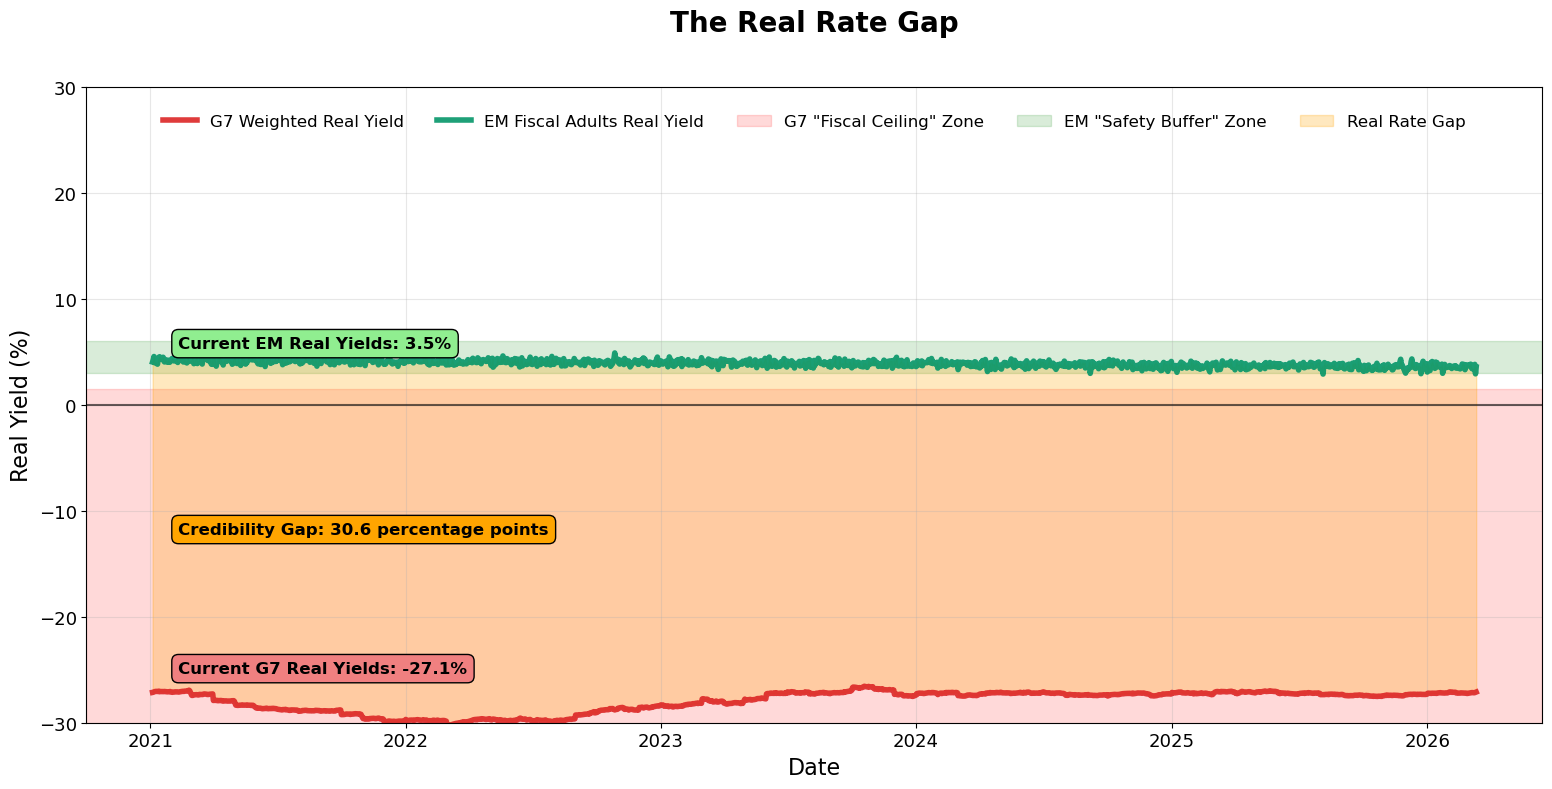

Chart 1 generated!
Key Insight: 30.6pp real yield advantage for EM fiscal adults


In [ ]:
# ===== Chart 1: Real Rate Gap (UPDATED - data coordinate annotations) =====
fig1, ax1 = plt.subplots(1, 1, figsize=(16, 8))
ax1.set_ylim(-30, 30)

# Plot lines
ax1.plot(chart1_data.index, chart1_data['G7_Real_Yield'], 
         label='G7 Weighted Real Yield', linewidth=4, color='#dc2626', alpha=0.9)
ax1.plot(chart1_data.index, chart1_data['EM_Real_Yield'], 
         label='EM Fiscal Adults Real Yield', linewidth=4, color='#059669', alpha=0.9)

# Zones and reference line
ax1.axhspan(-35, 1.5, alpha=0.15, color='red', label='G7 "Fiscal Ceiling" Zone')
ax1.axhspan(3.0, 6.0, alpha=0.15, color='green', label='EM "Safety Buffer" Zone')
ax1.axhline(y=0, color='black', linestyle='-', alpha=0.6, linewidth=1.5)

# Fill between
ax1.fill_between(chart1_data.index, chart1_data['G7_Real_Yield'], chart1_data['EM_Real_Yield'], 
                 alpha=0.25, color='orange', label='Real Rate Gap')

# Get last values from the actual plotted data
last_em_val = float(chart1_data['EM_Real_Yield'].iloc[-1])
last_g7_val = float(chart1_data['G7_Real_Yield'].iloc[-1])
gap_midpoint = (last_em_val + last_g7_val) / 2.0

print(f"ANNOTATION POSITIONS => EM: {last_em_val:.2f}, G7: {last_g7_val:.2f}, Mid: {gap_midpoint:.2f}")

# x position: use a date near the left edge
x_left = chart1_data.index[int(len(chart1_data) * 0.02)]

# Place labels at EXACT data y-values (pure data coords, no transform)
ax1.text(x_left, last_em_val + 1.5, f'Current EM Real Yields: {current_em_real:.1f}%',
         bbox=dict(boxstyle="round,pad=0.4", facecolor="lightgreen"),
         fontsize=12, fontweight='bold', va='bottom')

ax1.text(x_left, last_g7_val + 1.5, f'Current G7 Real Yields: {current_g7_real:.1f}%',
         bbox=dict(boxstyle="round,pad=0.4", facecolor="lightcoral"),
         fontsize=12, fontweight='bold', va='bottom')

ax1.text(x_left, gap_midpoint, f'Credibility Gap: {current_gap:.1f} percentage points',
         bbox=dict(boxstyle="round,pad=0.4", facecolor="orange"),
         fontsize=12, fontweight='bold', va='center')

ax1.set_title('The Real Rate Gap', 
              fontsize=20, fontweight='bold', pad=40)
ax1.set_ylabel('Real Yield (%)', fontsize=16)
ax1.set_xlabel('Date', fontsize=16)
ax1.legend(fontsize=12, loc='upper center', bbox_to_anchor=(0.5, 0.98), ncol=5, frameon=False)
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='both', which='major', labelsize=13)

plt.tight_layout()
fig1.savefig('chart1_real_rate_gap.png', dpi=300, bbox_inches='tight', facecolor='white')
fig1.savefig('chart1_real_rate_gap.pdf', bbox_inches='tight', facecolor='white')
plt.show()

print("Chart 1 generated!")
print(f"Key Insight: {current_gap:.1f}pp real yield advantage for EM fiscal adults")

## Chart 2: The Fiscal Divergence - Primary Surplus Trajectories

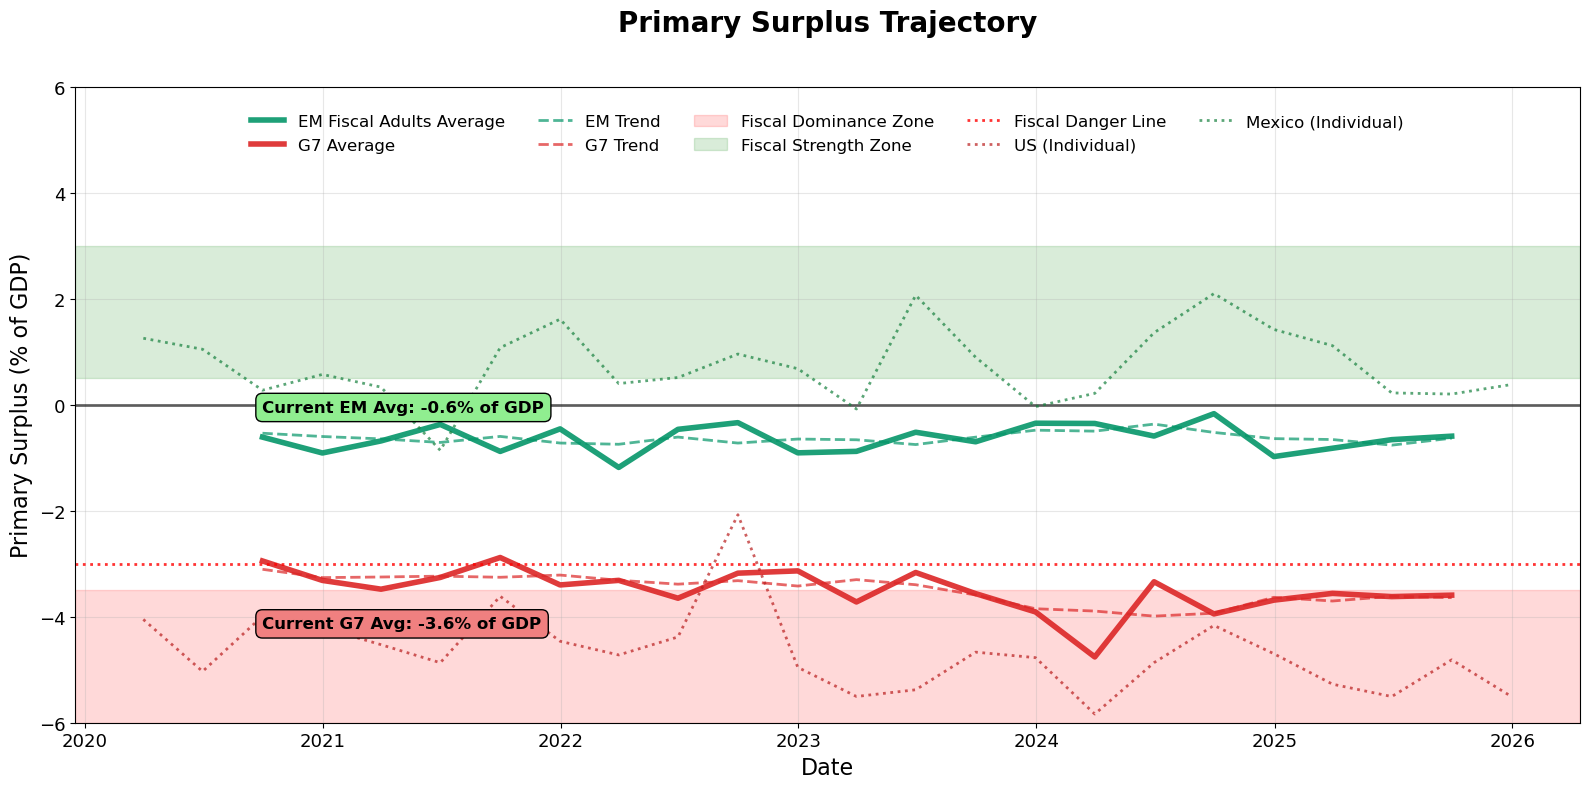

Chart 2 generated!
EM surplus: -0.6%, G7 surplus: -3.6%


In [ ]:
# Create Chart 2: Primary Surplus Trajectories (Real World Bank Data)
if 'chart2_data' not in dir() or chart2_data.empty:
    print("⚠️ No fiscal data available for Chart 2. Check World Bank API output above.")
else:
    fig2, ax2 = plt.subplots(1, 1, figsize=(16, 8))
    ax2.set_ylim(-12, 6)

    # Primary surplus trends (with markers for annual data)
    ax2.plot(chart2_data.index, chart2_data['EM_Surplus_Avg'],
             linewidth=3, color='#059669', label='EM Fiscal Adults Average', alpha=0.9,
             marker='o', markersize=7)
    ax2.plot(chart2_data.index, chart2_data['G7_Surplus_Avg'],
             linewidth=3, color='#dc2626', label='G7 Average', alpha=0.9,
             marker='o', markersize=7)

    # Add trend lines
    if 'EM_Trend' in chart2_data.columns:
        ax2.plot(chart2_data.index, chart2_data['EM_Trend'],
                 linewidth=2, color='#059669', linestyle='--', alpha=0.7, label='EM Trend (3yr)')
    if 'G7_Trend' in chart2_data.columns:
        ax2.plot(chart2_data.index, chart2_data['G7_Trend'],
                 linewidth=2, color='#dc2626', linestyle='--', alpha=0.7, label='G7 Trend (3yr)')

    # Mark fiscal zones
    ax2.axhspan(-12.0, -3.5, alpha=0.10, color='red', label='Fiscal Dominance Zone')
    ax2.axhspan(0.5, 6.0, alpha=0.10, color='green', label='Fiscal Strength Zone')
    ax2.axhline(y=0, color='black', linestyle='-', alpha=0.6, linewidth=2)
    ax2.axhline(y=-3.0, color='red', linestyle=':', alpha=0.8, linewidth=2, label='Fiscal Danger Line')

    # Add individual country trajectories if available
    if 'United States' in g7_surplus and 'Mexico' in em_surplus:
        ax2.plot(g7_surplus['United States'].index, g7_surplus['United States'],
                 color='#b91c1c', alpha=0.7, linewidth=2, linestyle=':', marker='s',
                 markersize=5, label='United States (Individual)')
        ax2.plot(em_surplus['Mexico'].index, em_surplus['Mexico'],
                 color='#15803d', alpha=0.7, linewidth=2, linestyle=':', marker='s',
                 markersize=5, label='Mexico (Individual)')

    # Annotations
    current_em_surplus = float(chart2_data['EM_Surplus_Avg'].iloc[-1])
    current_g7_surplus = float(chart2_data['G7_Surplus_Avg'].iloc[-1])
    x_left = chart2_data.index[0]

    ax2.text(x_left, current_em_surplus + 0.4, f'Current EM Avg: {current_em_surplus:.1f}% of GDP',
             bbox=dict(boxstyle='round,pad=0.4', facecolor='lightgreen'),
             fontsize=12, fontweight='bold', va='bottom')
    ax2.text(x_left, current_g7_surplus - 0.4, f'Current G7 Avg: {current_g7_surplus:.1f}% of GDP',
             bbox=dict(boxstyle='round,pad=0.4', facecolor='lightcoral'),
             fontsize=12, fontweight='bold', va='top')

    ax2.set_title('Primary Surplus Trajectory',
                  fontsize=20, fontweight='bold', pad=40)
    ax2.set_ylabel('Net Lending/Borrowing (% of GDP)', fontsize=16)
    ax2.set_xlabel('Year', fontsize=16)
    ax2.legend(fontsize=11, loc='upper center', bbox_to_anchor=(0.5, 0.98), ncol=4, frameon=False)
    ax2.grid(True, alpha=0.3)
    ax2.tick_params(axis='both', which='major', labelsize=13)

    # Source annotation
    ax2.text(0.99, 0.01, 'Source: World Bank (GC.NLD.TOTL.GD.ZS)',
             transform=ax2.transAxes, fontsize=9, color='gray',
             ha='right', va='bottom')

    plt.tight_layout()
    fig2.savefig('chart2_primary_surplus.png', dpi=300, bbox_inches='tight', facecolor='white')
    fig2.savefig('chart2_primary_surplus.pdf', bbox_inches='tight', facecolor='white')
    plt.show()

    print('Chart 2 generated!')
    current_divergence = chart2_data['Fiscal_Divergence'].iloc[-1]
    print(f'EM surplus: {current_em_surplus:.1f}%, G7 surplus: {current_g7_surplus:.1f}%')
